In [1]:
# Copyright 2025 Google LLC

# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at

# https://www.apache.org/licenses/LICENSE-2.0

# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [2]:
!pip install --upgrade https://github.com/google-deepmind/nuclease-design.git

# SETUP

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from zero_shot_sampling import alignment
from zero_shot_sampling import batch_selection_utils
from zero_shot_sampling import msa_vae
from zero_shot_sampling import sampling
from nuclease_design import constants as nuclease_constants


# SETUP

In [4]:
VAE_MODEL_FILE = '/tmp/vae_zero_shot/vae_model'

In [5]:
# Edits will only be made between these indices in the unaligned parent sequence.
DESIGN_REGION_START = nuclease_constants.G4_N_DESIGN_SEQUENCE_START
DESIGN_REGION_END = nuclease_constants.G4_N_DESIGN_SEQUENCE_END

# Number of samples to draw from the model.
NUM_CANDIDATES = 1000

# Size of the final selected batch, which will be a subset of the candidates.
LIBRARY_SIZE = 250

# The output batch should have a distribution of num_edits from the parent
# sequence that roughly follows this distribution.
DISTANCE_PROPORTIONS = {n: 11 - n for n in range(2, 10)}

# In the output batch, no substitution should appear in more than this many
# sequences.
MAX_MUTATION_USAGE = 50

In [6]:
vae_model, homolog_config = msa_vae.load(VAE_MODEL_FILE)

# Define a helper function for analyzing samples

In [7]:
def analyze_spliced_samples(
    samples, aligned_parent_seq, design_region_start, design_region_end
):

  _, axes = plt.subplots(1, 2, figsize=(15, 5))
  sample_df = alignment.get_spliced_sequence_df(
      samples,
      aligned_parent_seq,
      design_region_start,
      design_region_end,
  )

  axes = list(axes)[::-1]
  ax = axes.pop()
  sns.histplot(sample_df['sequence'].apply(len), discrete=True, ax=ax)
  ax.set_xlabel('Sequence length')

  ax = axes.pop()
  sns.histplot(data=sample_df, x='num_edits', discrete=True, ax=ax)
  ax.set_xlabel('Number of edits')

# Draw some raw samples

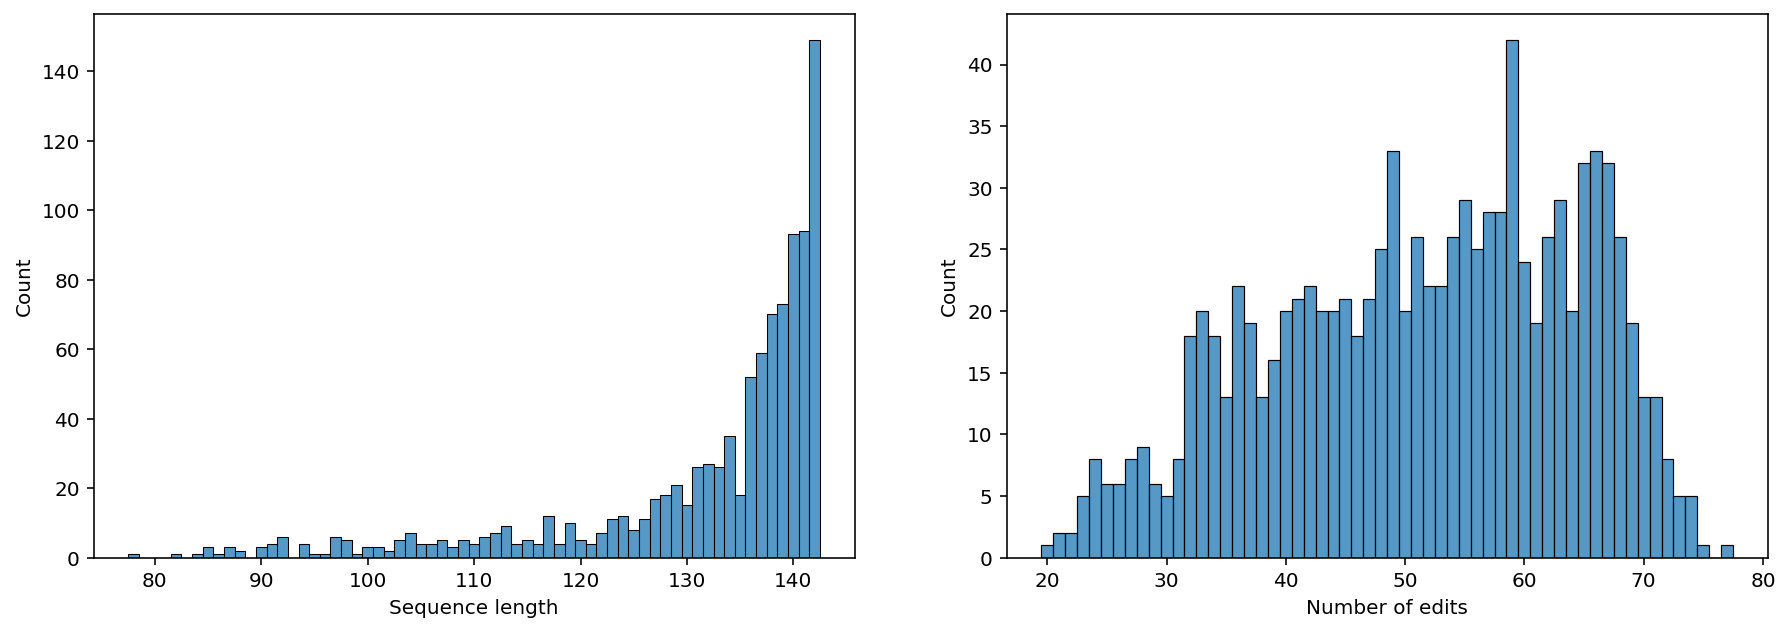

In [8]:
int_samples = vae_model.sample(NUM_CANDIDATES).numpy()
samples = homolog_config.match_state_domain.decode(int_samples)

analyze_spliced_samples(
    samples,
    homolog_config.match_state_parent,
    DESIGN_REGION_START,
    DESIGN_REGION_END
)

# Draw some neighboring variants

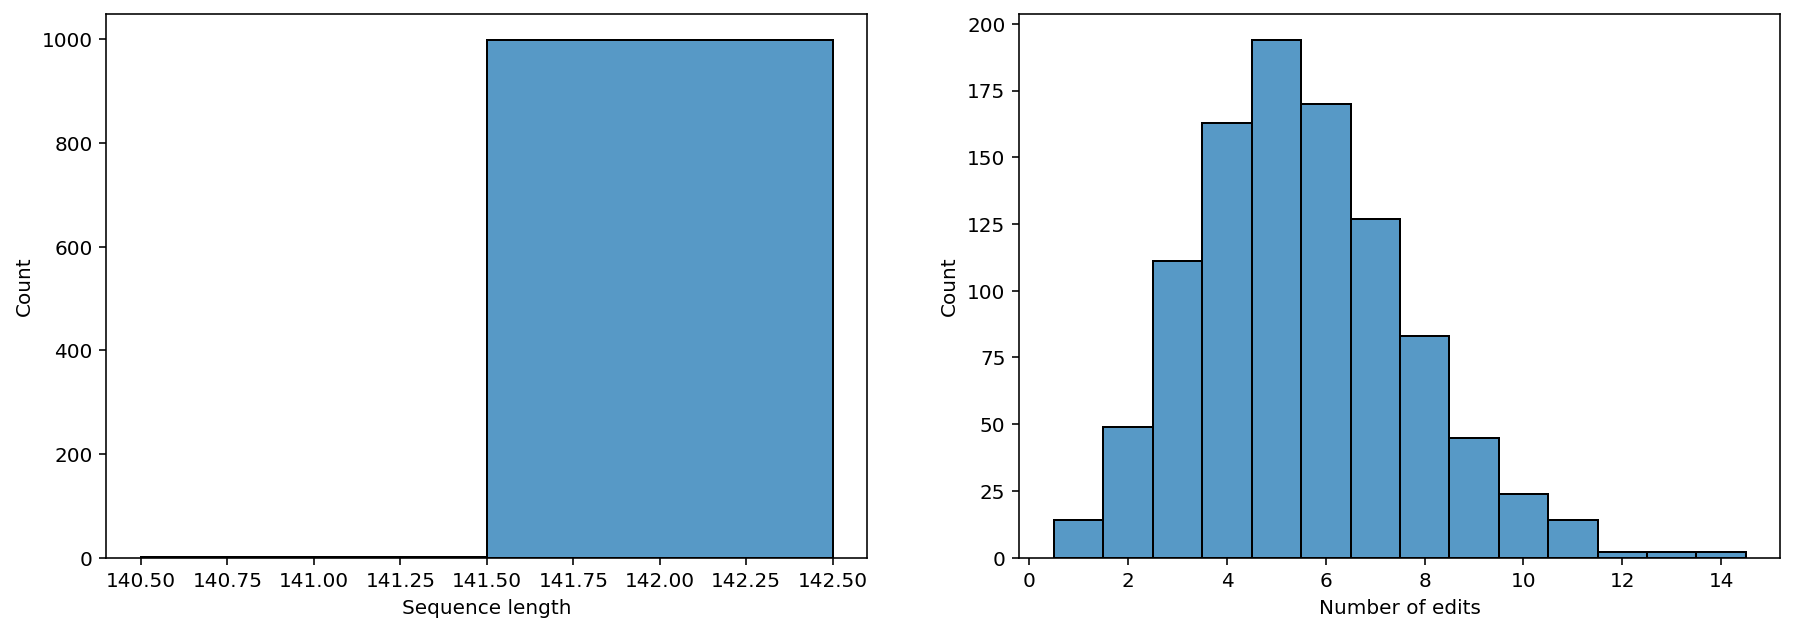

In [9]:
samples = sampling.sample_variants_from_vae(
    NUM_CANDIDATES, vae_model, homolog_config, random_state=np.random.RandomState(0)
)

analyze_spliced_samples(
    samples,
    homolog_config.match_state_parent,
    DESIGN_REGION_START,
    DESIGN_REGION_END
)

# Rejection sample to get variants satisfying edit constraints

Accepted 1020 samples out of 1024 total.


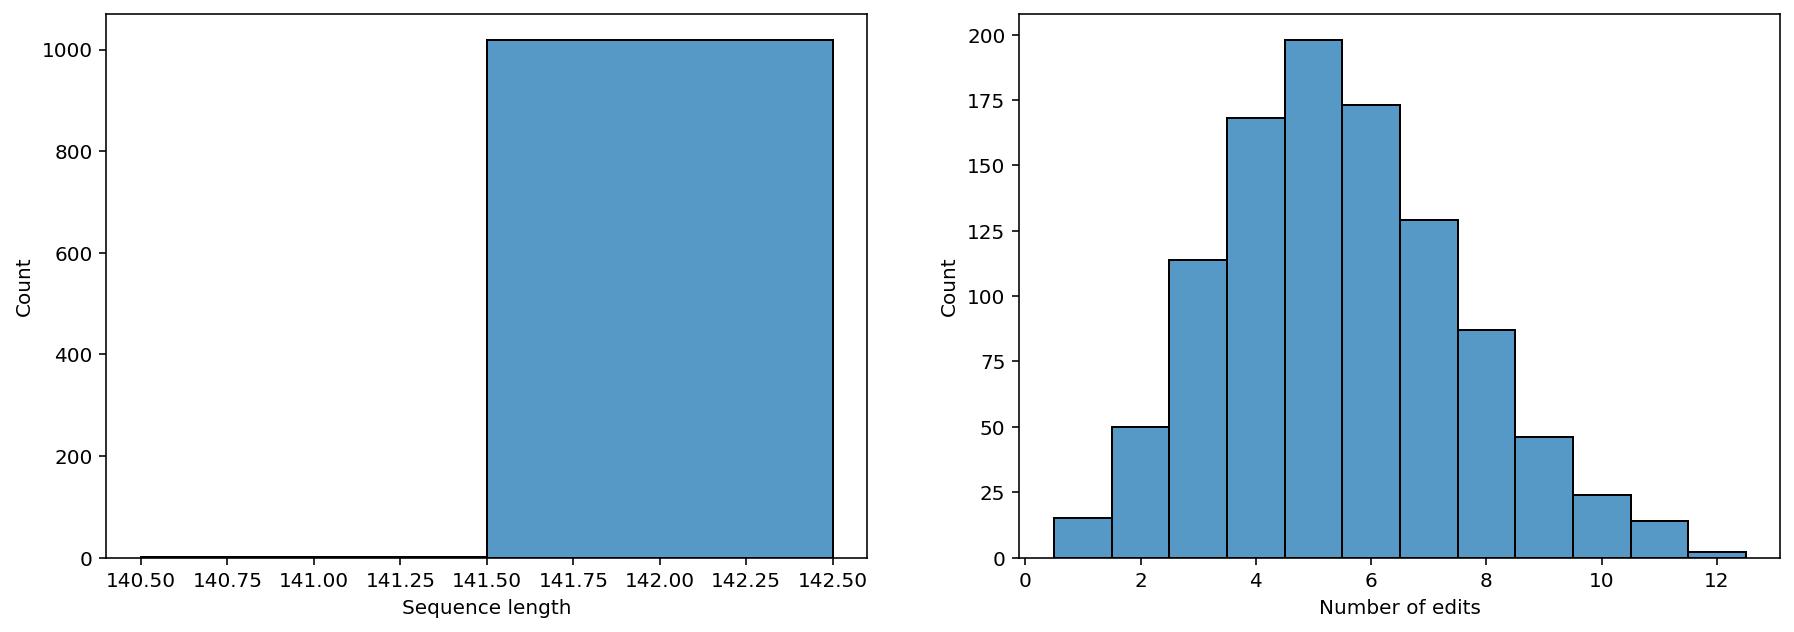

In [10]:
def sample_variants_from_vae_with_edit_constraints(
    num_samples,
    vae_model,
    homolog_config,
    max_num_insertions,
    max_num_deletions,
    max_num_substitutions,
    design_region_start,
    design_region_end,
    random_state: np.random.RandomState,
    sampling_batch_size: int = 512,
    max_num_proposals: int = int(1e6),
):

  sample_fn = lambda random_state: sampling.sample_variants_from_vae(
      num_samples=sampling_batch_size,
      vae_model=vae_model,
      homolog_config=homolog_config,
      random_state=random_state,
      sampling_batch_size=sampling_batch_size,
  )

  feasibility_fn = alignment.get_design_region_feasibility_fn(
      homolog_config.match_state_parent,
      max_num_insertions=max_num_insertions,
      max_num_deletions=max_num_deletions,
      max_num_substitutions=max_num_substitutions,
      design_region_start=design_region_start,
      design_region_end=design_region_end,
  )

  samples = sampling.rejection_sample(
      sample_fn,
      feasibility_fn,
      num_samples,
      random_state=random_state,
      max_num_proposals=max_num_proposals,
  )

  return samples


samples = sample_variants_from_vae_with_edit_constraints(
    NUM_CANDIDATES,
    vae_model,
    homolog_config,
    max_num_insertions=2,
    max_num_deletions=2,
    max_num_substitutions=12,
    design_region_start=DESIGN_REGION_START,
    design_region_end=DESIGN_REGION_END,
    random_state=np.random.RandomState(0),
    sampling_batch_size=512,
)


analyze_spliced_samples(
    samples,
    homolog_config.match_state_parent,
    DESIGN_REGION_START,
    DESIGN_REGION_END
)

# Select a final batch of samples

We use a greedy algorithm that attempts to select `LIBRARY_SIZE` samples with the highest total 'score' subject to the following constraints:
* The distribution of distances of selected samples from the parent sequence follows `DISTANCE_PROPORTIONS`.
* No substitution is used more than `MAX_MUTATION_USAGE` times.

Below, we set 'score' to be uniform across all candidate samples, but in other
settings it may be advantageous to use a model-predicted score, such as the prediction from some supervised model.


Also, sometimes it may not be possible to select `LIBRARY_SIZE` samples satisfying these constraints. If this occurs, you can draw more samples above.
If again that doesn't work, set `EXPAND_CANDIDATES_BY_REMOVING_HEAVY_HITTER_SUBSTITUTIONS` to True. This generates new pseudo-samples by removing some of the frequently-occurring substitutions.



In [11]:
# You should first try running with this set to False. See comment above.
EXPAND_CANDIDATES_BY_REMOVING_HEAVY_HITTER_SUBSTITUTIONS = True

# Deduplicate the samples
samples = list(set(samples))


sample_df = alignment.get_spliced_sequence_df(
    samples,
    homolog_config.match_state_parent,
    DESIGN_REGION_START,
    DESIGN_REGION_END,
)

if EXPAND_CANDIDATES_BY_REMOVING_HEAVY_HITTER_SUBSTITUTIONS:
  expanded_edits = (
      batch_selection_utils.expand_edits_by_removing_heavy_hitter_substitutions(
          sample_df['edits'], top_n=10, max_num_substitutions_to_remove=3
      )
  )
  expanded_samples = [
      alignment.apply_edits(edits, homolog_config.match_state_parent)
      for edits in expanded_edits
  ]
  sample_df = alignment.get_spliced_sequence_df(
      expanded_samples,
      homolog_config.match_state_parent,
      DESIGN_REGION_START,
      DESIGN_REGION_END,
  )


# Within a group defined by grouping_col, we select the rows by 'score'.
# Here, we use uniform scores, but in other settings these could be predictions
# of a supervised model, etc.
sample_df['score'] = 1.0

selected_df = (
    batch_selection_utils.select_top_from_groups_with_mutation_usage_constraint(
        sample_df,
        num_to_select=LIBRARY_SIZE,
        group_col='num_edits',
        mutations_col='substitutions',
        group_proportions=DISTANCE_PROPORTIONS,
        sort_column='score',
        sort_ascending=False,
        random_state=np.random.RandomState(0),
        max_mutation_usage=MAX_MUTATION_USAGE,
    )
)


observed_max_mutation_usage = (
    selected_df['edits']
    .explode()
    .value_counts()
    .reset_index()
    .rename(columns=dict(edits='edit'))
    .iloc[0]
)
print(
    'Number of usages of the most frequent edit:'
    f' {observed_max_mutation_usage["count"]} for edit'
    f' {observed_max_mutation_usage["edit"]}'
)
assert observed_max_mutation_usage['count'] <= MAX_MUTATION_USAGE

if len(selected_df) < LIBRARY_SIZE:
  raise ValueError(
      f'Size of selected library: {len(selected_df)} is less that LIBRARY_SIZE'
      f' = {LIBRARY_SIZE}. You should first try generating a larger set of'
      ' samples from model. If that does not work, try re-running with'
      ' EXPAND_CANDIDATES_BY_REMOVING_HEAVY_HITTER_SUBSTITUTIONS = True. If'
      ' that does not work, try increasing MAX_MUTATION_USAGE or changing the'
      ' flags to batch_selection_utils.remove_heavy_hitter_substitutions.'
  )

Number of usages of the most frequent edit: 50 for edit ('A', 62, 'S')


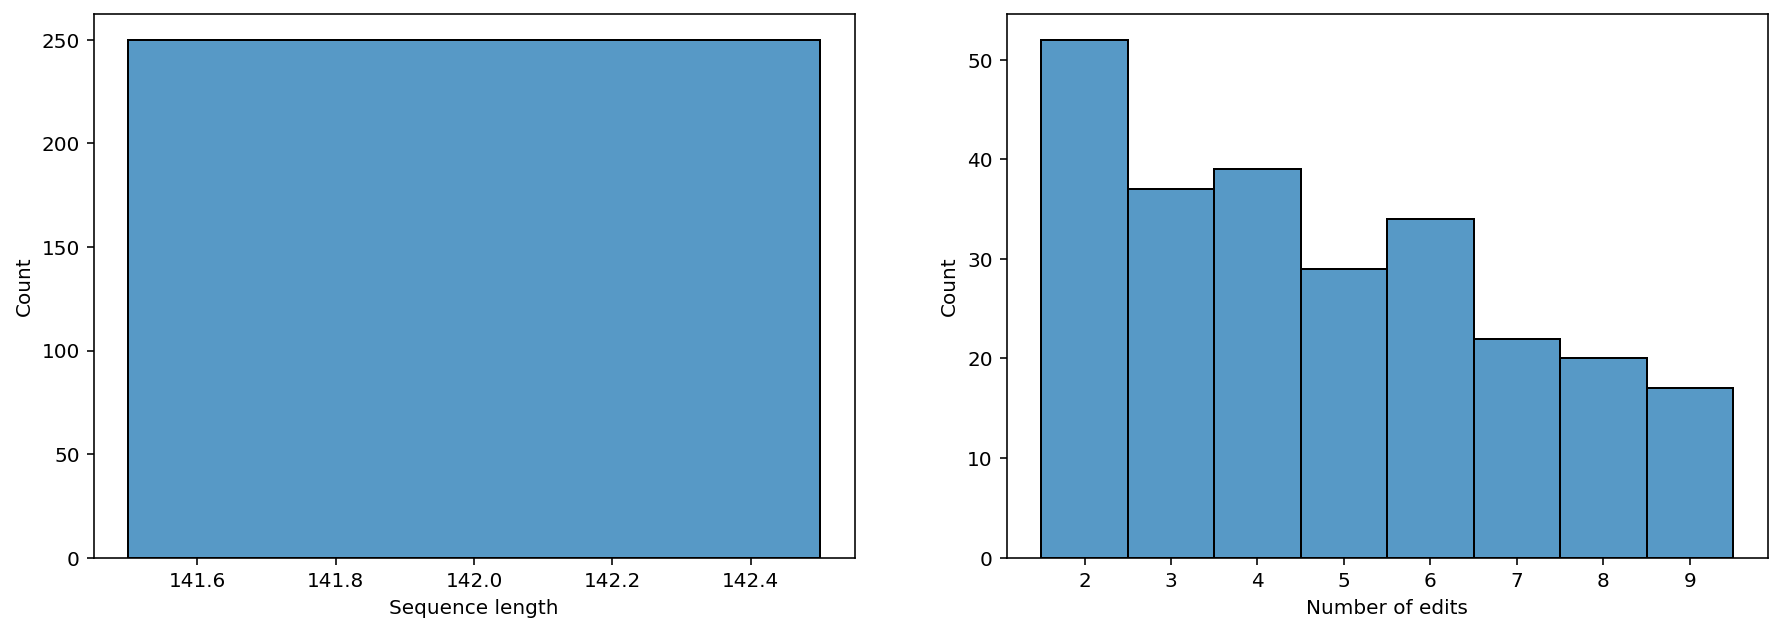

In [12]:
analyze_spliced_samples(
    selected_df['aligned_sequence'],
    homolog_config.match_state_parent,
    DESIGN_REGION_START,
    DESIGN_REGION_END
)

# Sanity check that the actual distance proportions are similar to the target ones

If these distributions are too different, you may need to relax the `max_mutation_usage` constraint or change the target proportions.

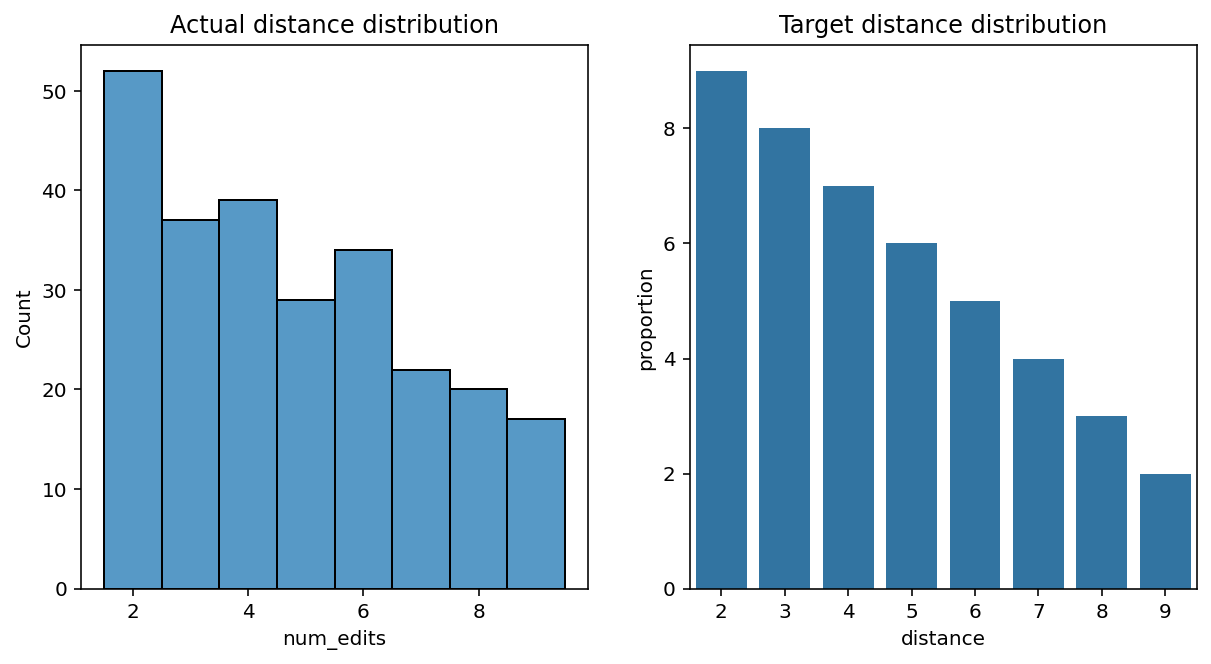

In [13]:
_, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(x=selected_df['num_edits'], discrete=True, ax=axes[0])
axes[0].set_title('Actual distance distribution')

sns.barplot(
    data=pd.DataFrame(
        list(DISTANCE_PROPORTIONS.items()), columns=['distance', 'proportion']
    ),
    x='distance',
    y='proportion',
    ax=axes[1],
    color=sns.color_palette()[0],
)
_ = axes[1].set_title('Target distance distribution')